# `spsa-sumo` — SPSA calibration against a production simulator (Balakrishna 2007)

**What.** `spsa-sumo` is the T2 (`ADR-002`) estimation track's first GUARDED
estimator: Spall's (1992) simultaneous-perturbation stochastic approximation
(`[spall1992multivariate]`), but with its inner assignment ORACLE swapped for
a real production simulator — the shipped `sumo-marouter` adapter (adr-027) —
instead of the repo's in-process MSA/AON oracle. This is Balakrishna,
Ben-Akiva & Koutsopoulos' (2007) black-box simulator-in-the-loop calibration
paradigm (`[balakrishna2007offline]`,
[docs/REFERENCES.md](../../docs/REFERENCES.md)), made real: SPSA descends the
link-count misfit under `marouter`'s own hardcoded cost law, two simulator
runs per iteration.

**Why it is in the benchmark.** T2's whole thesis is that ANY OD-emitting
method — a 1980 balancing loop, a GLS solve, a simulator-in-the-loop
calibration — is scored by the SAME unchanged pinned-`bfw` certifier
(ADR-002 Decision 2). This row proves the thesis costs nothing extra: **zero**
changes to the task, runner, or certifier were needed to plug a real
subprocess engine in as the black box. See
[docs/design/adr-028-spsa-sumo.md](../../docs/design/adr-028-spsa-sumo.md) for
the full derivation (demand-ONLY scope; the joint demand+supply contribution
is honestly NOT shipped) and every measured anchor.

**Scope.** The `sp_calls=0` disclosure (never fabricated) and the
`sp_calls`-only budget refusal it forces, a certified recovery anchor through
the UNCHANGED pinned-`bfw` certifier, and the box-projection lesson (a REAL
adversarial-review finding: an earlier draft emitted a point different from
the one it certified — P1 broken by an evaluation-time-only clip).

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every
scored quantity below — `od_feasible`, `certificate_gap`, `obs_count_rmse`,
`od_rmse` — comes from the SAME `ODCertifier` every other T2 estimator here
is scored by, re-assigning the emitted OD through its own pinned `bfw`
reference, never from `spsa-sumo`'s self-report
([README](../../README.md), *Certified, not self-reported*).

In [1]:
# Setup. `spsa-sumo`'s inner oracle is `sumo-marouter`, so it needs the
# optional `sumo` extra (`pip install tabench[sumo]`) -- guarded exactly like
# `src/tabench/models/__init__.py`, the FIRST guarded T2 estimator
# (`estimation/__init__.py`).
#
# The inline backend is Agg-based: figures render headlessly into the
# notebook, so CI can execute tutorials without a display. NEVER
# matplotlib.use("Agg") in-kernel -- it silently suppresses inline capture.
%matplotlib inline
try:
    import sumo  # noqa: F401  (the eclipse-sumo wheel; absence -> ModuleNotFoundError)
except ModuleNotFoundError as exc:
    if exc.name != "sumo":
        raise
    raise ModuleNotFoundError(
        "spsa-sumo needs the optional 'sumo' extra: pip install tabench[sumo]"
    ) from exc

from tabench import Budget, PriorBaseline, run_estimation_experiment, two_route_scenario, viz
from tabench.estimation import ESTIMATOR_REGISTRY, SumoSPSAEstimator

assert "spsa-sumo" in ESTIMATOR_REGISTRY
caps = SumoSPSAEstimator.capabilities
print(f"paradigm         : {caps.paradigm}")
print(f"deterministic    : {caps.deterministic}  (seeded, macroreplicated)")
print(f"seedable         : {caps.seedable}")
print(f"provides_gap     : {caps.provides_gap}")

paradigm         : estimation
deterministic    : False  (seeded, macroreplicated)
seedable         : True
provides_gap     : False


## The `sp_calls=0` disclosure, and the fabricated-`sp_calls` trap it prevents

`marouter` exposes no shortest-path (Dijkstra) count. The tempting shortcut —
charging `2 * k_inner` per SPSA iteration as a stand-in `sp_calls`, since
each iteration runs two inner solves — would FABRICATE a hardware-free work
unit the engine never actually reports. `spsa-sumo` instead discloses
`sp_calls = 0` on every checkpoint, and refuses an `sp_calls`-only budget up
front (it cannot bound a loop on an axis the oracle does not expose) rather
than silently ignoring it.

In [2]:
_RECOVERY_EST = {
    "sensors": {"kind": "explicit", "links": [0, 2]},
    "heldout": {"kind": "explicit", "links": [1, 3]},
    "noise": "none",
    "n_periods": 3,
    "prior": {"kind": "stale", "cv": 0.3},
}
scenario = two_route_scenario(sue_theta=None)

res_disclosure = run_estimation_experiment(
    scenario, [SumoSPSAEstimator(iters=5)], Budget(iterations=1000),
    seed=13, macroreps=1, estimation=_RECOVERY_EST,
)
sp_rows = [r for r in res_disclosure.rows if r["estimator"] == "spsa-sumo"]
print(f"checkpoints : {len(sp_rows)}, all sp_calls==0 : {all(r['sp_calls'] == 0 for r in sp_rows)}")
assert all(r["sp_calls"] == 0 for r in sp_rows)

try:
    run_estimation_experiment(
        scenario, [SumoSPSAEstimator(iters=3)], Budget(sp_calls=500),
        seed=0, macroreps=1, estimation=_RECOVERY_EST,
    )
    raise AssertionError("expected an sp_calls-only budget to be refused")
except ValueError as exc:
    print(f"sp_calls-only budget refused : {exc}"[:110] + "…")

checkpoints : 5, all sp_calls==0 : True
sp_calls-only budget refused : spsa-sumo cannot honor an sp_calls-only budget (its marouter oracle exposes no …


## The recovery anchor, certified through the UNCHANGED pinned-`bfw` certifier

Clean counts, a stale prior, on the asymmetric two-route instance (never
Braess in CI — GitHub runners are slower than the dev box). Zero changes to
the task, runner, or certifier were needed for this row: `ODCertifier`
re-assigns the emitted OD through its OWN pinned `bfw` reference regardless
of which black box produced it — the whole point of T2.

In [3]:
res = run_estimation_experiment(
    scenario, [PriorBaseline(), SumoSPSAEstimator(iters=20)], Budget(iterations=1000),
    seed=13, macroreps=1, estimation=_RECOVERY_EST,
)
last = {row["estimator"]: row for row in res.rows}
prior, spsa = last["prior"], last["spsa-sumo"]

print(f"certified od_feasible          : {spsa['od_feasible']:.0f}")
print(f"certificate_converged          : {spsa['certificate_converged']:.0f}")
print(f"certificate_gap                : {float(spsa['certificate_gap']):.2e}")
print(f"obs_count_rmse  spsa-sumo/prior : {float(spsa['obs_count_rmse']):.4f} / "
      f"{float(prior['obs_count_rmse']):.4f}")
print(f"od_rmse         spsa-sumo/prior : {float(spsa['od_rmse']):.4f} / "
      f"{float(prior['od_rmse']):.4f}")

assert spsa["od_feasible"] == 1.0
assert spsa["certificate_converged"] == 1.0
assert abs(float(spsa["certificate_gap"])) < 1e-6
assert float(spsa["obs_count_rmse"]) < 0.6 * float(prior["obs_count_rmse"])  # loose: ~5x measured
assert float(spsa["od_rmse"]) < 0.6 * float(prior["od_rmse"])

certified od_feasible          : 1
certificate_converged          : 1
certificate_gap                : 0.00e+00
obs_count_rmse  spsa-sumo/prior : 0.0665 / 0.3509
od_rmse         spsa-sumo/prior : 0.0892 / 0.4708


## The box-projection lesson (adr-028 Decision 6, a real adversarial-review finding)

Balakrishna et al. impose a box constraint on the demand estimate. An EARLIER
draft applied it only inside the oracle hook (`_assign_obs`), invisible to
the parent SPSA loop: the loss was measured at the CLIPPED point while
best-iterate tracking stored the RAW out-of-box candidate — so a binding box
once emitted an out-of-box OD whose self-report described a DIFFERENT point
(P1 broken: emitted != evaluated). The fix surfaces the thesis's own two
projections as loop hooks (`_project`/`_project_log`) applied BEFORE `loss()`
and best-iterate tracking. Demonstrated live: a seed where the box genuinely
binds (a far, stale prior + a tight ceiling below truth).

In [4]:
HI_FRAC = 3.0
est = SumoSPSAEstimator(iters=12, c=0.8, step_clip=2.0, demand_hi_frac=HI_FRAC)
res_box = run_estimation_experiment(
    scenario, [est], Budget(iterations=1000), seed=14, macroreps=1,
    estimation={**_RECOVERY_EST, "prior": {"kind": "stale", "cv": 0.6}},
)
box_rows = [r for r in res_box.rows if r["estimator"] == "spsa-sumo"]
assert box_rows and all(r["od_feasible"] == 1.0 for r in box_rows)

hi = float(est._hi_vec[0])  # 3 * prior[0, 1] on the single active OD pair
emitted = float(res_box.bundles[("spsa-sumo", "m0")].final.od_matrix[0, 1])
print(f"box ceiling (3x prior) : {hi:.4f}")
print(f"emitted demand         : {emitted:.4f}  (the box BINDS -- SPSA wants to climb past it)")
assert emitted <= hi + 1e-9  # in-box: fails under a clip-removal mutation of _project

last_box = box_rows[-1]
honesty_diff = abs(float(last_box["self_obs_count_rmse"]) - float(last_box["obs_mean_count_rmse"]))
print(f"self-report vs certified honesty diff : {honesty_diff:.4f}  "
      "(collapses to the mapping-floor scale -- the fix)")
assert honesty_diff < 0.05

box ceiling (3x prior) : 2.6691
emitted demand         : 2.6691  (the box BINDS -- SPSA wants to climb past it)
self-report vs certified honesty diff : 0.0005  (collapses to the mapping-floor scale -- the fix)


## Visualize

The certified artifact is the emitted OD's re-assigned link flows on a road
`Network`, so `tabench.viz` applies (adr-035's viz rule).

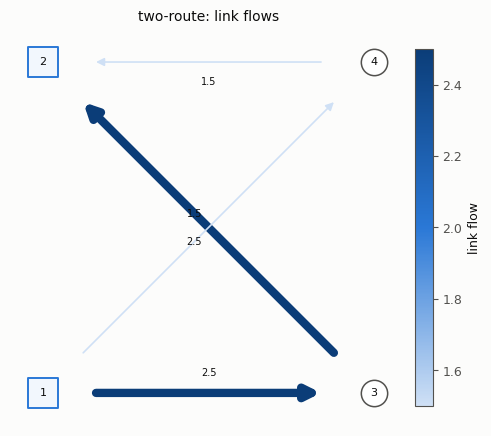

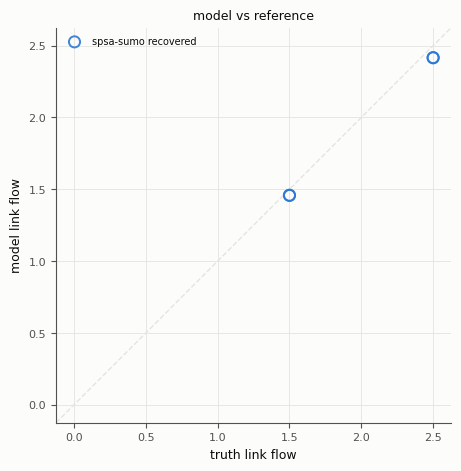

In [5]:
from tabench import BiconjugateFrankWolfeModel, Demand, RngBundle, Scenario, Trace

# two_route_scenario carries no built-in ReferenceSolution; recompute the truth
# assignment in-cell (never quoted), the same _pinned_ue pattern the `spsa`
# tutorial uses.
truth_trace = Trace()
BiconjugateFrankWolfeModel().solve(
    scenario, Budget(iterations=5000, target_relative_gap=1e-10), RngBundle(0), truth_trace
)
truth_flows = truth_trace.final.link_flows

recovered_trace = Trace()
BiconjugateFrankWolfeModel().solve(
    Scenario("spsa-sumo-recovered", scenario.network, Demand(res.bundles[("spsa-sumo", "m0")].final.od_matrix)),
    Budget(iterations=5000, target_relative_gap=1e-10), RngBundle(0), recovered_trace,
)
display(viz.plot_network_flows(scenario.network, truth_flows))
display(viz.plot_flow_scatter(
    ("truth", truth_flows),
    {"spsa-sumo recovered": recovered_trace.final.link_flows},
))

## Takeaways & pointers

- **Zero certificate changes.** `ODCertifier` scored this row through the
  identical pinned-`bfw` map every other T2 estimator uses — the T2 thesis's
  whole point, proven by construction here.
- **Disclosed, never fabricated.** `sp_calls=0` on every checkpoint, and the
  budget contract refuses an axis the oracle cannot honor rather than
  quietly ignoring it.
- **A real adversarial-review fix, not a hypothetical.** The box-projection
  regression above is the exact repro that caught P1 broken (emitted ≠
  evaluated) in an earlier draft — demonstrated, not just described.
- **Where next.** `dtalite-tap`
  ([03-dtalite-tap.ipynb](03-dtalite-tap.ipynb)) for the second external
  engine; the joint demand+supply scope that is honestly NOT shipped here, and
  the corner-plateau caveat it inherits, in
  [docs/design/adr-028-spsa-sumo.md](../../docs/design/adr-028-spsa-sumo.md).